# HMM Segmentation on Real cDNA Display ONT Data

In [1]:
import sys, os, pathlib, tomllib

sys.path.insert(0, os.path.abspath('.'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import poreflow as pf

from logic.segment import (
    build_model,
    shade_regions,
    REGION_TO_STATE,
    STATE_TO_REGION,
    REGION_COLORS,
)

## Load Config

In [2]:
with open("poreflow.toml", "rb") as f:
    config = tomllib.load(f)

folder_path  = pathlib.Path(config["input"]["folder_path"])
file_name    = config["input"]["file_name"]
resample_to  = config["input"]["resample_to_freq"]

print(f"File : {folder_path / file_name}")
print(f"Resample to : {resample_to} Hz")

File : /Users/iravaidya/Documents/Bachelors/BEP/raw_data/TUD257703_20251215_FBE41737_MN45752_sequencing_run_C011_D_67671.fast5
Resample to : 5000 Hz


## Build HMM from Simulated Training Data

> **Note:** The model emission parameters are estimated from the simulated CSV database.  
> If the segmentation looks wrong on real data, re-estimate the means/stds from real labelled events or fit them by eye.

In [3]:
db       = pd.read_csv("data/nanopore_trace_database.csv")
train_db = db[db["trace_id"] < 500]

model = build_model(train_db)

print("HMM emission means  (pA) :", model.means_.flatten())
print("HMM emission covars (pA²):", model.covars_.flatten())

HMM emission means  (pA) : [78.84529292 79.46668698]
HMM emission covars (pA²): [218.43671036 323.27384614]


## Find Events in One Channel via Poreflow

In [18]:
CHANNEL = 7 # change to whichever channel you want to test

with pf.File(folder_path / file_name) as f:
    raw = f.get_raw(CHANNEL)

raw = raw.downsample(resample_to).apply_filter(config["input"]["filter_freq"])

events = raw.find_events(**config["event_finding"])

if events is None or len(events) == 0:
    raise RuntimeError(f"No events found in channel {CHANNEL}")

events = events.filter_by_duration(config["event_filtering"]["min_duration"], verbose=True)
print(f"\nFound {len(events)} events in channel {CHANNEL}")
print(events.head())

Found 37 events from 37 with a duration of 1.0 seconds or longer.

Found 37 events in channel 7
   start_idx  end_idx   n_pts  start_time  end_time  duration         ios  \
0      60004   368136  308132     12.0008   73.6272   61.6264  268.370219   
1     396797   668776  271979     79.3594  133.7552   54.3958  267.777767   
2     698283   968729  270446    139.6566  193.7458   54.0892  267.277734   
3    1023772  1268976  245204    204.7544  253.7952   49.0408  266.815821   
4    1325314  1331553    6239    265.0628  266.3106    1.2478  266.570794   

   channel  quality  label  
0        7      0.0      0  
1        7      0.0      0  
2        7      0.0      0  
3        7      0.0      0  
4        7      0.0      0  


## Apply HMM Segmentation to Each Event

In [19]:
results = []

raw_current = raw[pf.CURRENT_COL].values  # full channel current array

for row_idx, ev in events.iterrows():
    start   = int(ev[pf.START_IDX_COL])
    end     = int(ev[pf.END_IDX_COL])
    current = raw_current[start:end]
    ios     = float(ev[pf.IOS_COL])

    if len(current) < 20:
        continue

    pred_states = model.predict(current.reshape(-1, 1))
    t_ms        = np.arange(len(current)) * (1000.0 / resample_to)

    results.append({
        "row_idx":     row_idx,
        "current":     current,
        "pred_states": pred_states,
        "t_ms":        t_ms,
        "ios":         ios,
    })

print(f"Segmented {len(results)} events")

# Fraction predicted as each region
all_preds = np.concatenate([r["pred_states"] for r in results])
for state, region in STATE_TO_REGION.items():
    print(f"  {region:>8}: {np.mean(all_preds == state):.1%}")

Segmented 37 events
       DNA: 16.1%
   non-DNA: 83.9%


## Visualize: Grid of Segmented Events

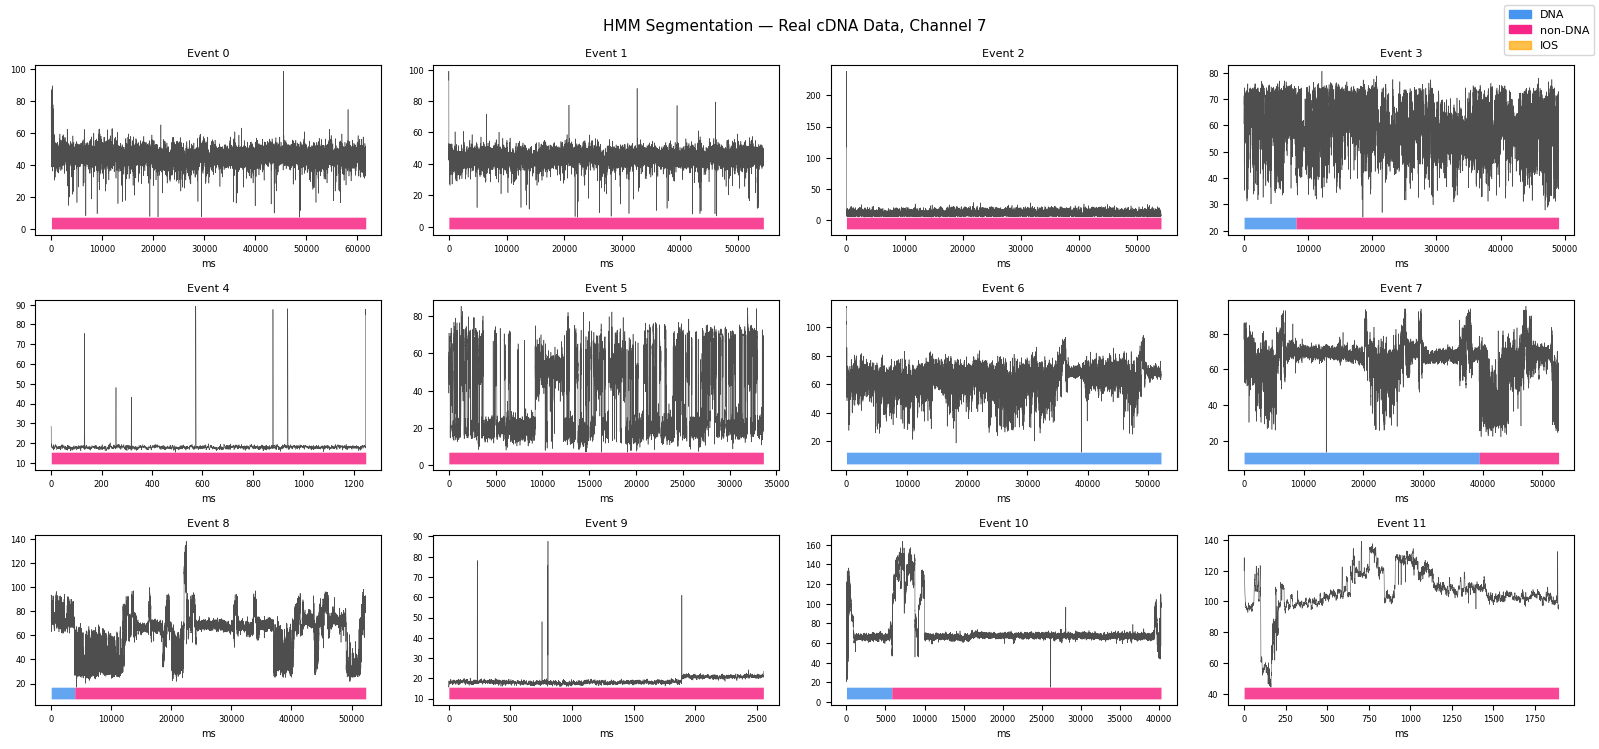

In [20]:
N_SHOW = min(len(results), 12)
ncols  = 4
nrows  = (N_SHOW + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 2.5), squeeze=False)

for i, res in enumerate(results[:N_SHOW]):
    ax      = axes[i // ncols][i % ncols]
    t, I    = res["t_ms"], res["current"]
    ymin, ymax = I.min(), I.max()
    band    = (ymax - ymin) * 0.08

    shade_regions(ax, t, res["pred_states"], ymin - band, ymin)
    ax.plot(t, I, color="#222", lw=0.4, alpha=0.8)
    ax.axhline(res["ios"], color="orange", linestyle="--", lw=0.8, alpha=0.7, label="IOS")
    ax.set_ylim(ymin - band * 1.5, ymax + band * 0.5)
    ax.set_title(f"Event {res['row_idx']}", fontsize=8)
    ax.set_xlabel("ms", fontsize=7)
    ax.tick_params(labelsize=6)

for i in range(N_SHOW, nrows * ncols):
    axes[i // ncols][i % ncols].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches.append(mpatches.Patch(color="orange", alpha=0.7, label="IOS"))
fig.legend(handles=legend_patches, loc="upper right", fontsize=8)
fig.suptitle(f"HMM Segmentation — Real cDNA Data, Channel {CHANNEL}", fontsize=11)
plt.tight_layout()
plt.show()

## Inspect a Single Event in Detail

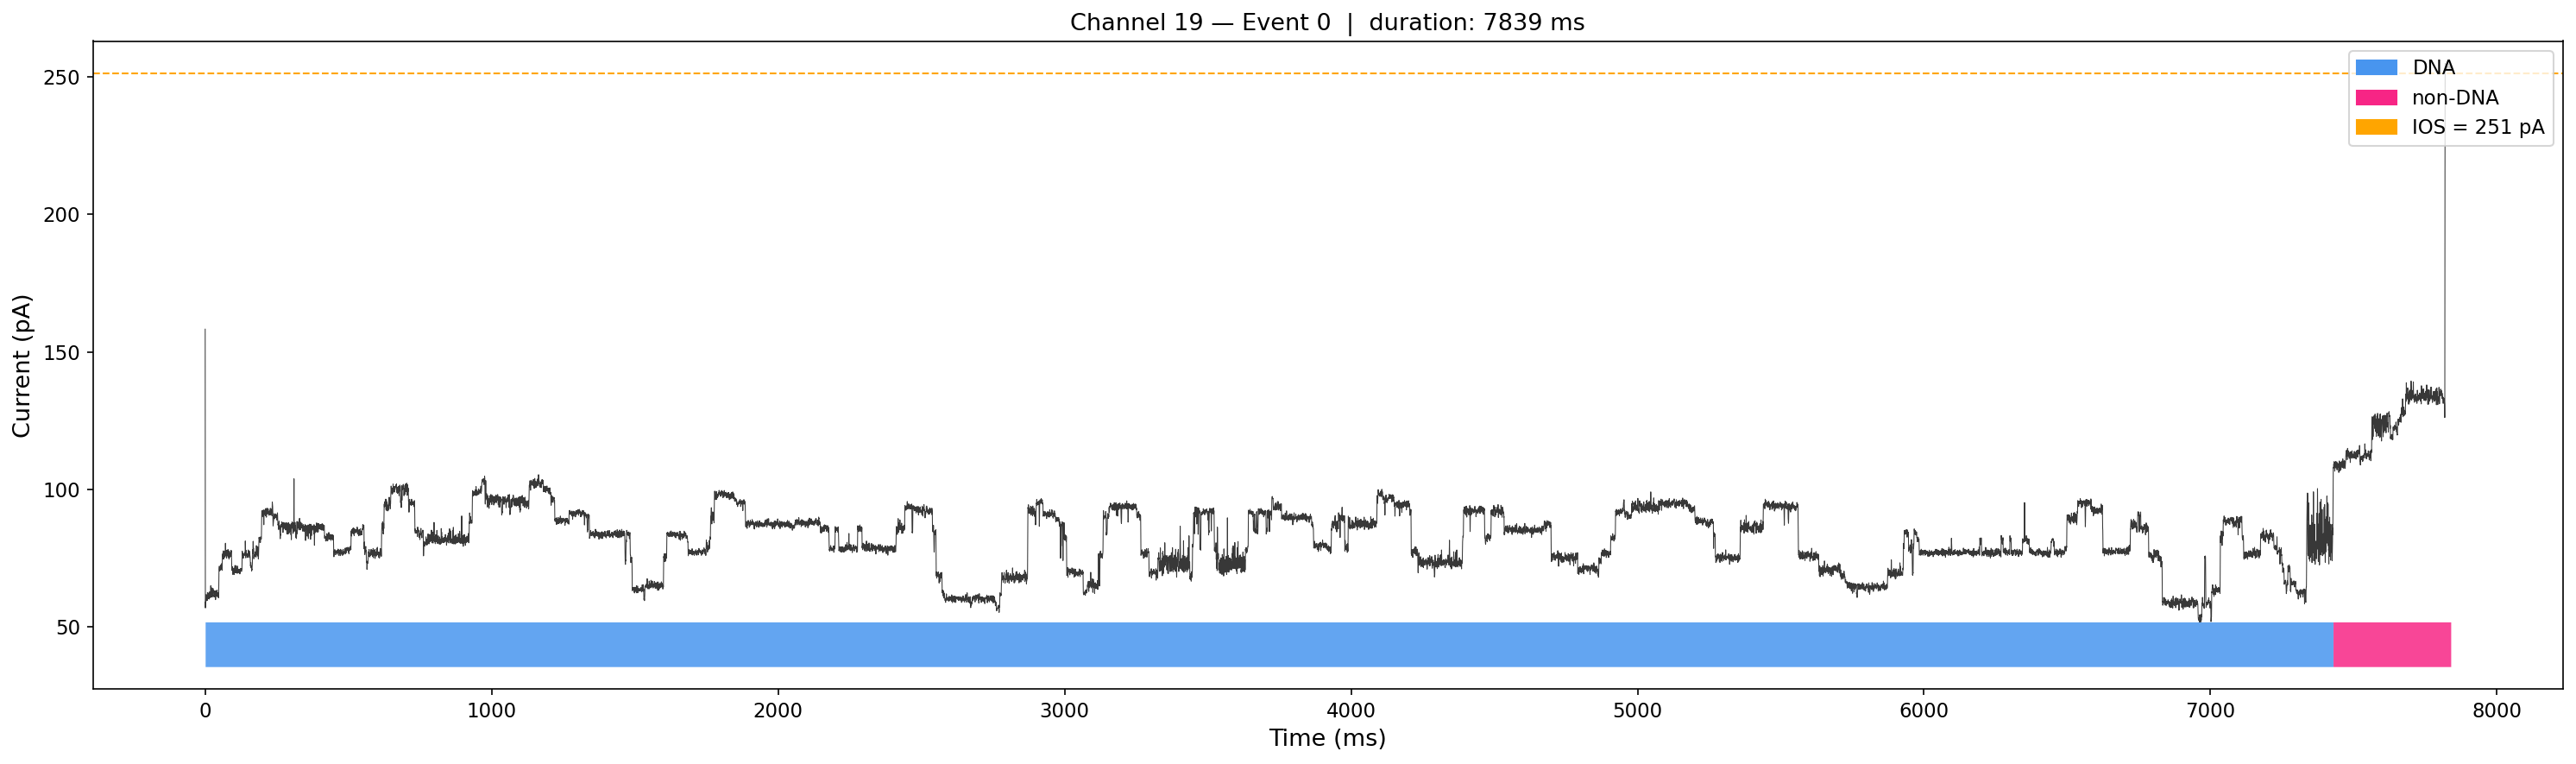

Predicted region fractions:
       DNA: 94.8%  (7428 ms)
   non-DNA: 5.2%  (411 ms)


In [145]:
EVENT_IDX = 0   # index into `results` (not the raw event index)

res = results[EVENT_IDX]
t, I = res["t_ms"], res["current"]

fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

ymin, ymax = I.min(), I.max()
band = (ymax - ymin) * 0.08

shade_regions(ax, t, res["pred_states"], ymin - band, ymin)
ax.plot(t, I, color="#222", lw=0.5, alpha=0.9)
ax.axhline(res["ios"], color="orange", linestyle="--", lw=1, label=f"IOS = {res['ios']:.0f} pA")

ax.set_ylim(ymin - band * 1.5, ymax + band * 0.5)
ax.set_xlabel("Time (ms)", fontsize=13)
ax.set_ylabel("Current (pA)", fontsize=13)
ax.tick_params(labelsize=11)
ax.set_title(f"Channel {CHANNEL} — Event {res['row_idx']}  |  duration: {t[-1]:.0f} ms", fontsize=13)

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches.append(mpatches.Patch(color="orange", label=f"IOS = {res['ios']:.0f} pA"))
ax.legend(handles=legend_patches, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

# Per-region fraction
print("Predicted region fractions:")
for state, region in STATE_TO_REGION.items():
    frac = np.mean(res["pred_states"] == state)
    dur  = frac * t[-1]
    print(f"  {region:>8}: {frac:.1%}  ({dur:.0f} ms)")

# Extracting peptide part


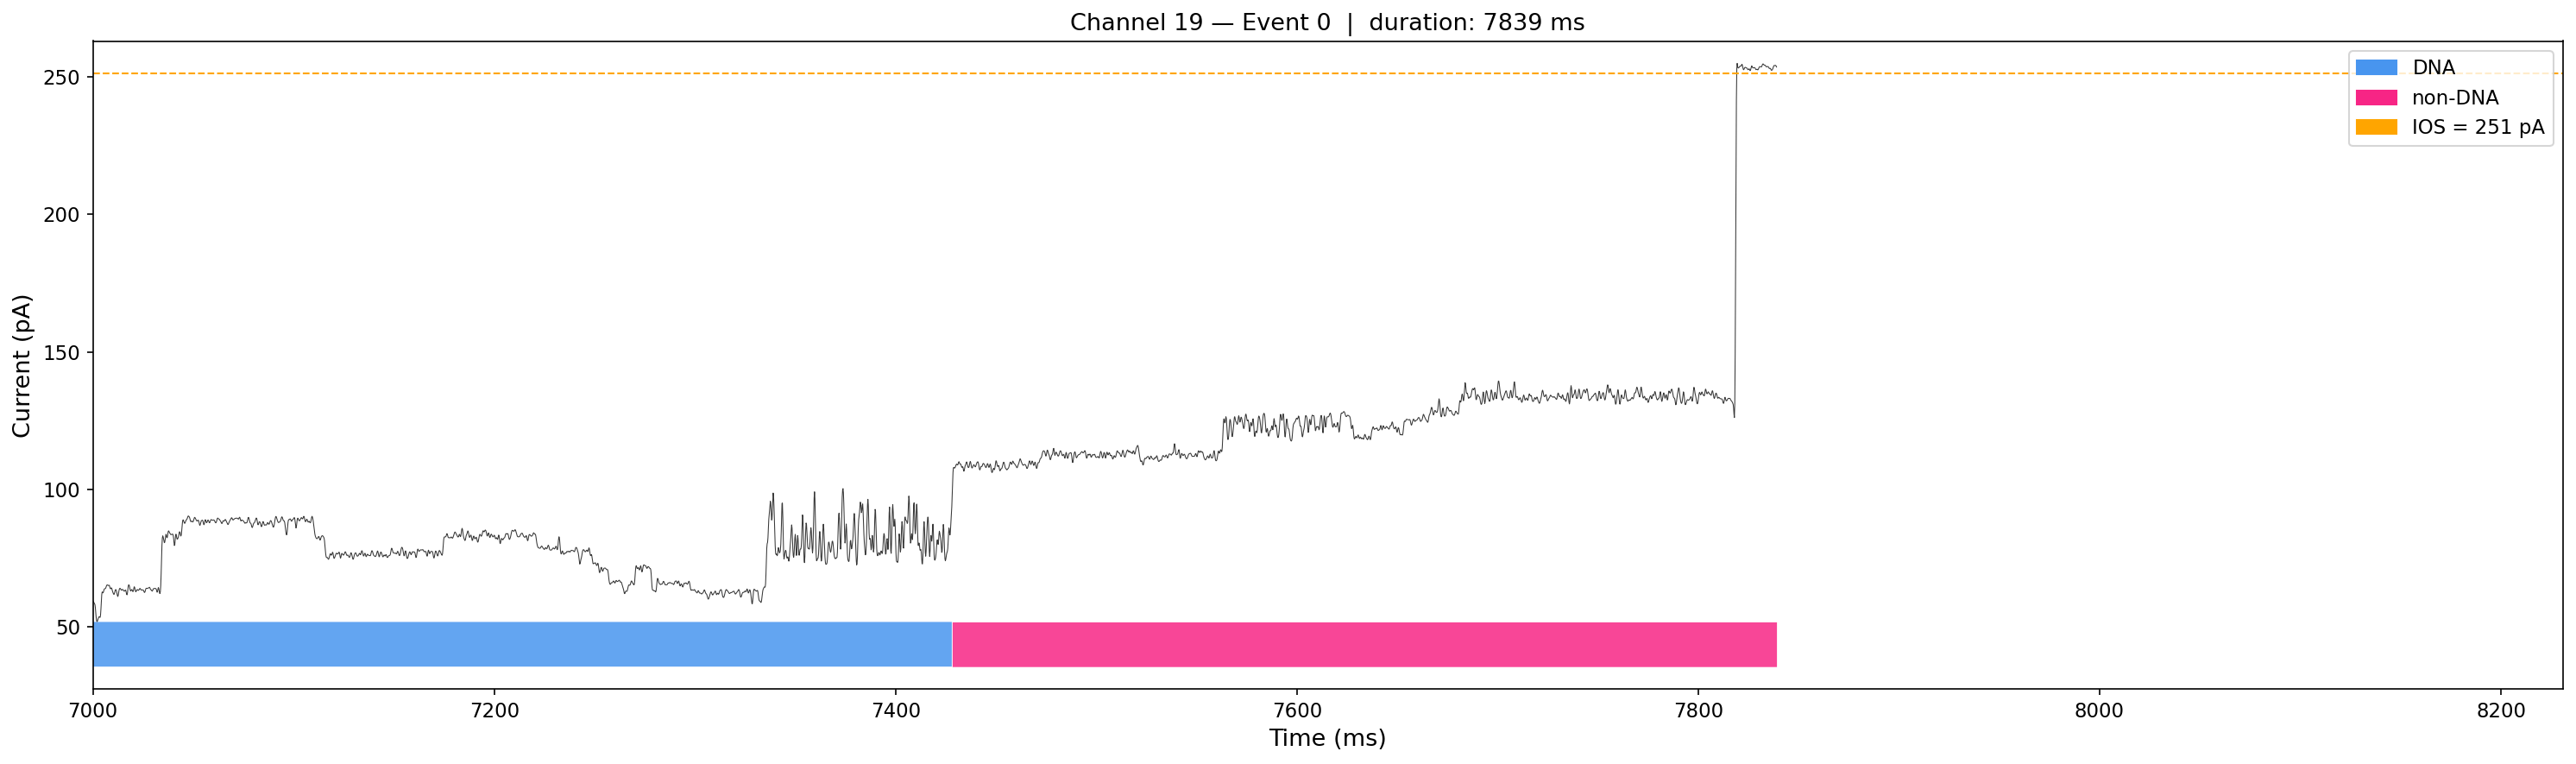

In [151]:
EVENT_IDX = 0   # index into `results` (not the raw event index)

res = results[EVENT_IDX]
t, I = res["t_ms"], res["current"]

fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

ymin, ymax = I.min(), I.max()
band = (ymax - ymin) * 0.08

shade_regions(ax, t, res["pred_states"], ymin - band, ymin)
ax.plot(t, I, color="#222", lw=0.5, alpha=0.9)
ax.axhline(res["ios"], color="orange", linestyle="--", lw=1, label=f"IOS = {res['ios']:.0f} pA")

ax.set_ylim(ymin - band * 1.5, ymax + band * 0.5)
ax.set_xlim(7000, )
ax.set_xlabel("Time (ms)", fontsize=13)
ax.set_ylabel("Current (pA)", fontsize=13)
ax.tick_params(labelsize=11)
ax.set_title(f"Channel {CHANNEL} — Event {res['row_idx']}  |  duration: {t[-1]:.0f} ms", fontsize=13)

legend_patches = [mpatches.Patch(color=c, label=r) for r, c in REGION_COLORS.items()]
legend_patches.append(mpatches.Patch(color="orange", label=f"IOS = {res['ios']:.0f} pA"))
ax.legend(handles=legend_patches, fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()



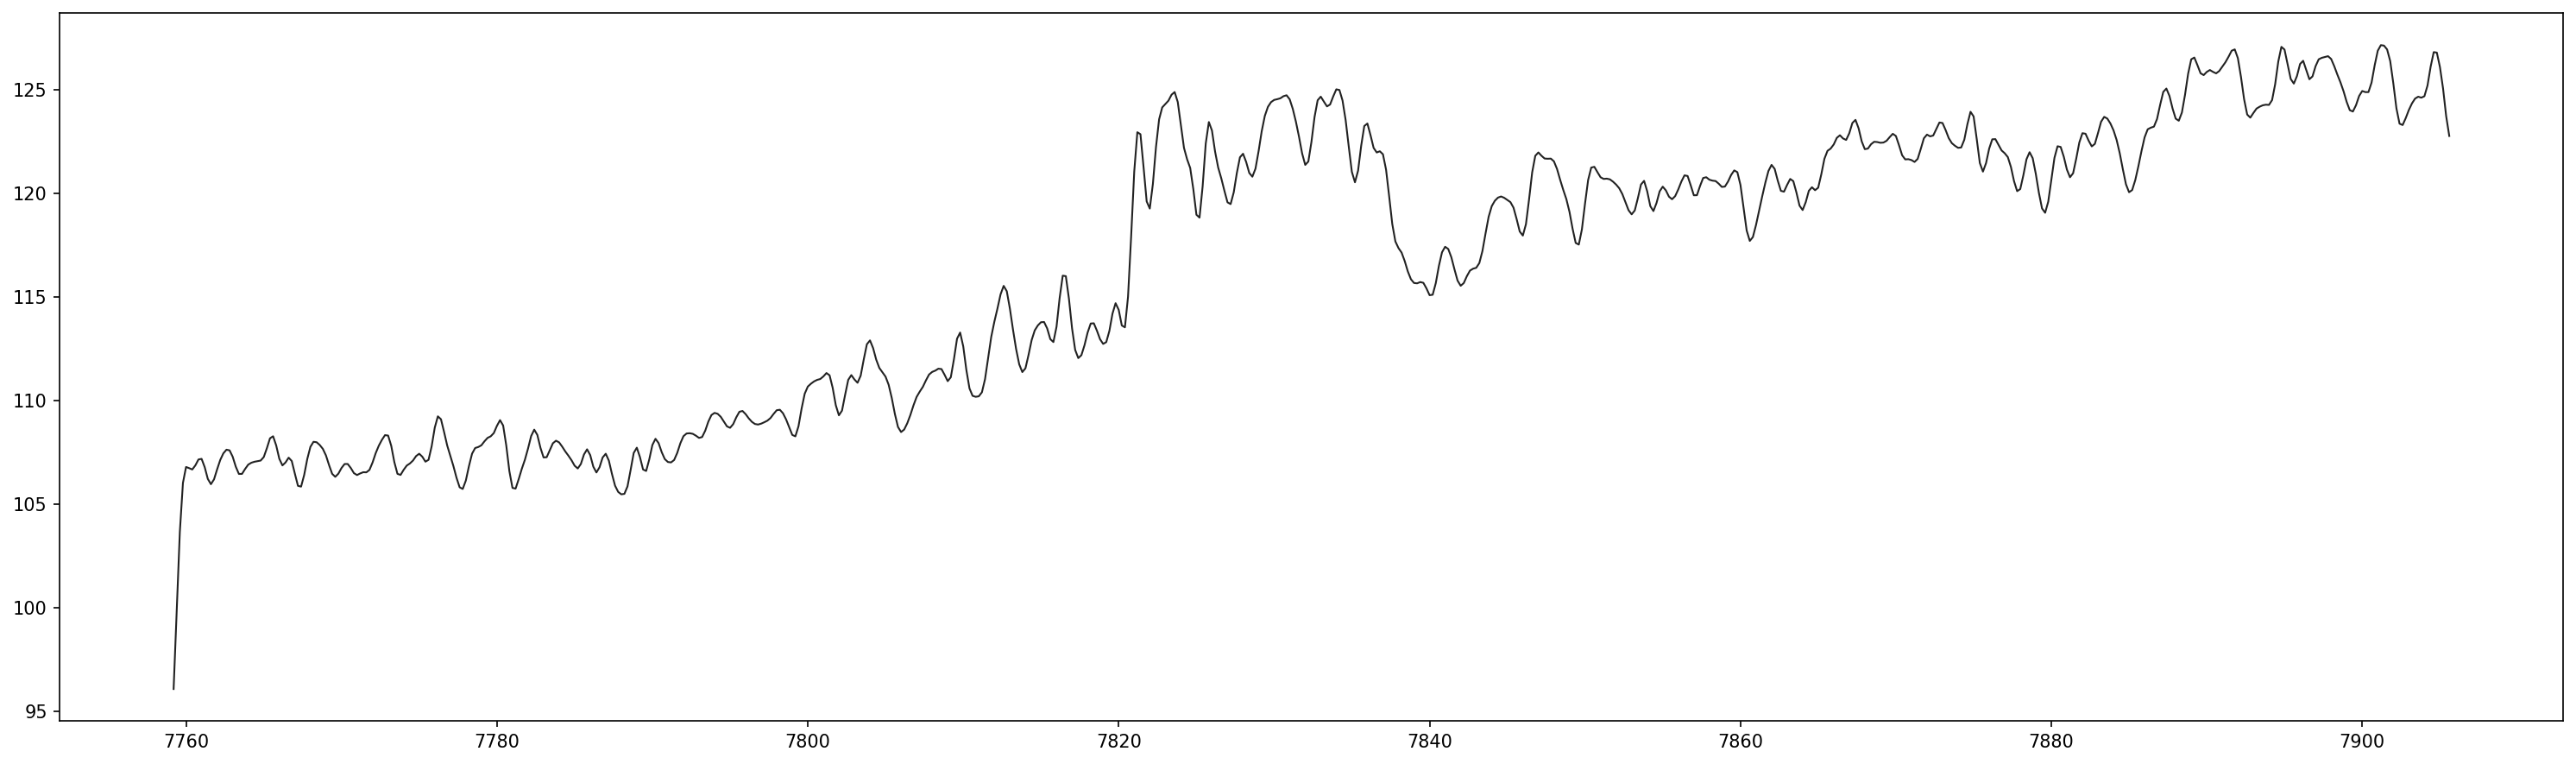

In [152]:
peptide_mask    = pred_states == 1          # boolean array, same length as current
peptide_current = current[peptide_mask]     # just the peptide samples
peptide_t_ms    = t_ms[peptide_mask]        # matching time axis

fig, ax = plt.subplots(figsize=(20, 6), dpi=150)

# ymin, ymax = I.min(), I.max()
# band = (ymax - ymin) * 0.08
ax.plot(peptide_t_ms, peptide_current, color="#222", lw=1, alpha=1)
plt.tight_layout()

plt.show()

In [153]:
from poreflow.steps import changepoint
steps = changepoint.get_steps(peptide_current, sfreq=5000)


In [3]:
from logic.database import WINDOW_HALF
import numpy as np

def extract_features(steps):
    features = []
    means = steps["mean"].values  # array of per-step means, easy to index

    for i in range(len(steps)):
        ratio = [np.exp(-j**2 / 2.0) for j in range(-WINDOW_HALF, WINDOW_HALF + 1)]

        m2 = means[i-2] if i >= 2 else np.nan
        m1 = means[i-1] if i >= 1 else np.nan
        p1 = means[i+1] if i+1 < len(means) else np.nan
        p2 = means[i+2] if i+2 < len(means) else np.nan

        weighted = (ratio[0]*m2 + ratio[1]*m1 + ratio[2]*means[i] 
                    + ratio[3]*p1 + ratio[4]*p2)

        features.append({
            "mean_current":           means[i],
            "weighted_window_current": weighted,
            "mean_minus2":            m2,
            "mean_minus1":            m1,
            "mean_plus1":             p1,
            "mean_plus2":             p2,
        })

    return pd.DataFrame(features)

# feature_real_df = extract_features(steps)

In [10]:
train_raw = pd.read_csv('data/nanopore_feature_by_cluster.csv')

test_raw = pd.read_csv('data/randomcontrol_feature_by_cluster.csv')


# ios = results[EVENT_IDX]["ios"]  # ~251 pA
# train_raw_norm = train_raw.copy()
# current_cols = ['mean_current', 'weighted_window_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
# train_raw_norm[current_cols] = train_raw[current_cols] / ios

# test_raw_norm = test_raw.copy()
# test_raw_norm[current_cols] = test_raw[current_cols] / ios



In [11]:
from logic.cnn_logic_for_data import cnn_sweep

model_4, history_4, X_test_4, y_test_4 = cnn_sweep(
    n_clusters=4, train=train_raw, test=test_raw
    )

n_clusters = 4
model_4.save("my_model.keras")

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 20, 64)         │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 128)        │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 20, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 20, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20, 4)          │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,964 (785.02 KB)

 Trainable params: 200,324 (782.52 KB)

...

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8228 - loss: 0.4053 - val_accuracy: 0.8445 - val_loss: 0.3576 - learning_rate: 1.5625e-05
Epoch 41/100
  7/312 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.8353 - loss: 0.3985

/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


312/312 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8233 - loss: 0.4052 - val_accuracy: 0.8451 - val_loss: 0.3569 - learning_rate: 1.5625e-05


/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)
/Users/iravaidya/Documents/Bachelors/BEP/cDNAtlasProject/.venv/lib/python3.12/si

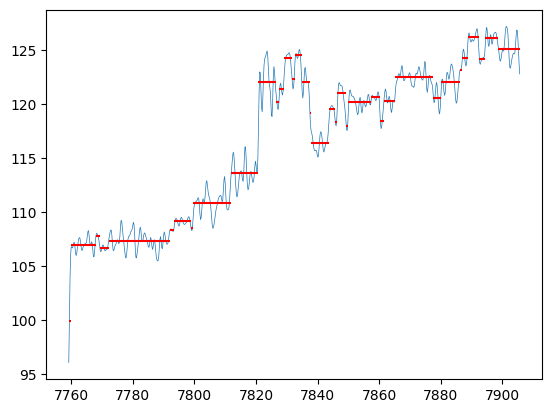

In [162]:
plt.plot(peptide_t_ms, peptide_current, lw=0.5)
for _, s in steps.iterrows():
    plt.hlines(s['mean'], peptide_t_ms[int(s['start_idx'])], peptide_t_ms[min(int(s['end_idx']), len(peptide_t_ms)-1)], color='red')

In [163]:
from logic.cnn_logic_for_data import predict_real_event

# ios = results[EVENT_IDX]["ios"]  # ~251 pA
# feature_real_df_norm = feature_real_df.copy()
# current_cols = ['mean_current', 'weighted_window_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
# feature_real_df_norm[current_cols] = feature_real_df[current_cols] / ios


pred_clusters, probs = predict_real_event(model_4, feature_real_df)
print(pred_clusters)  # array of 20 cluster labels, one per step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
[3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


In [159]:
from logic.clustering_cnn import get_clusters
smth = 'MDEVTQETSQDSGQETSQDSGQEGTQDSGQEGTQDSGQEGSXSGDYKDDDDKG'
smth_first_20 = smth[:20]

cluster_seq = []
n_clusters = 4
aa_to_cluster = get_clusters(n_clusters=n_clusters)
for aa in smth_first_20:
    cluster_seq.append(aa_to_cluster.get(aa, -1))  # -1 for unknown AAs
print(cluster_seq)
    



[2, 3, 3, 4, 4, 4, 3, 4, 3, 4, 3, 3, 3, 4, 3, 4, 3, 4, 3, 3]


In [91]:
print(train_raw['cluster_class'].value_counts(normalize=True))


cluster_class
1, other                    0.348573
4, small                    0.300489
3, large and hydrophobic    0.250094
2, negative                 0.100845
Name: proportion, dtype: float64


In [166]:
print("Real data mean_current range:", feature_real_df['mean_current'].describe())
print("Training mean_current range:", train_raw['mean_current'].describe())


Real data mean_current range: count     36.000000
mean     117.815551
std        6.835584
min       99.897805
25%      112.903220
50%      120.245390
75%      122.324341
max      126.154700
Name: mean_current, dtype: float64
Training mean_current range: count    199981.000000
mean         73.850163
std          13.902157
min          31.638191
25%          63.878753
50%          73.949400
75%          83.852886
max         114.216388
Name: mean_current, dtype: float64


In [ ]:
print(y_test_4[:1])       # true labels
preds = model_4.predict(X_test_4[:1])
print(np.argmax(preds, axis=-1) + 1)  # predicted



NameError: name 'y_test_4' is not defined

In [94]:
preds_sim = model_4.predict(X_test_4[:10])
pred_labels = np.argmax(preds_sim, axis=-1) + 1  # (10, 20)
print("Predicted:\n", pred_labels)
print("True:\n", y_test_4[:10] + 1)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 551ms/step
Predicted:
 [[2 3 2 4 3 3 2 2 2 2 3 2 2 3 3 1 4 2 4 1]
 [4 1 2 3 2 1 4 2 4 3 2 4 4 4 2 1 4 3 4 2]
 [2 3 4 4 4 4 3 4 3 1 2 2 4 4 3 3 1 1 4 4]
 [2 2 2 4 1 4 4 4 4 4 4 3 4 2 3 4 2 3 2 2]
 [4 4 1 3 3 4 3 1 2 1 4 4 4 3 3 3 1 2 4 2]
 [2 1 3 4 4 2 1 1 4 3 3 3 3 2 4 2 4 2 2 1]
 [4 2 1 3 4 4 3 2 2 1 1 3 3 4 1 3 3 1 4 4]
 [1 3 3 4 3 4 2 2 3 2 4 3 1 2 4 2 3 4 2 3]
 [4 2 3 3 4 4 4 3 3 1 2 1 4 3 1 4 4 2 3 3]
 [3 2 1 4 2 3 3 2 3 2 2 3 4 2 4 3 3 2 2 3]]
True:
 [[2 3 2 3 4 3 2 2 2 2 3 2 2 3 3 1 4 2 4 1]
 [4 1 2 3 2 1 4 2 4 3 2 4 2 4 2 1 4 3 4 2]
 [2 3 4 4 4 4 3 4 3 1 2 2 4 4 3 3 1 1 3 4]
 [2 4 2 3 1 4 4 4 4 4 3 4 4 2 3 4 2 3 2 2]
 [4 4 1 3 3 3 3 2 1 2 4 4 4 3 3 3 1 1 4 2]
 [2 1 3 4 4 2 1 1 4 3 3 3 3 1 4 1 3 2 2 1]
 [4 2 2 4 4 4 3 2 2 1 1 3 3 4 1 3 3 1 4 4]
 [1 3 3 4 4 3 1 2 3 2 4 3 1 2 4 2 3 4 2 3]
 [4 2 3 3 3 4 4 3 3 1 2 1 4 3 1 4 4 2 3 3]
 [3 2 1 4 2 3 3 2 3 2 2 3 4 4 4 3 3 2 2 3]]


# Trying with random data from literature


In [119]:
import scipy.io
import numpy as np

mat = scipy.io.loadmat('BCAR3.mat')
traces = mat['BCAR3'][0]  # array of 125 traces

# each trace is shape (1, n_samples) — squeeze to 1D
trace = traces[4].squeeze()
print(f"{len(traces)} traces, first trace: {len(trace)} samples, mean: {trace.mean():.1f} pA")


from poreflow.steps import changepoint

steps = changepoint.get_steps(trace, sfreq=1000, **config["step_finding"])
print(f"Steps found: {len(steps)}")

125 traces, first trace: 15436 samples, mean: 76.6 pA
Steps found: 87


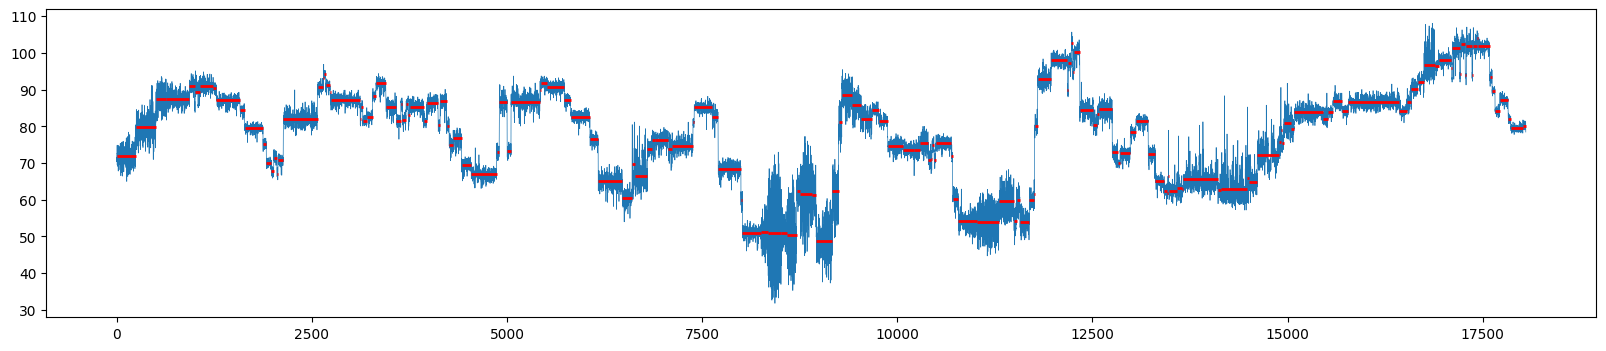

Trace duration: 18052 ms, steps: 173


In [126]:
trace = traces[8].squeeze()
steps = changepoint.get_steps(trace, sfreq=1000, sensitivity=1.5, min_level_length=10)

t_ms = np.arange(len(trace)) 

plt.figure(figsize=(20, 4))
plt.plot(t_ms, trace, lw=0.5)
for _, s in steps.iterrows():
    plt.hlines(s['mean'], t_ms[int(s['start_idx'])], 
               t_ms[min(int(s['end_idx']), len(t_ms)-1)], color='red', lw=2)
plt.show()
print(f"Trace duration: {t_ms[-1]:.0f} ms, steps: {len(steps)}")

In [ ]:
store = []
for boundary in range(50, 100):  # sweep through plausible DNA end positions
    peptide_steps = steps.iloc[boundary:boundary+12].reset_index(drop=True)
    features = extract_features(peptide_steps)
    pred, probs = predict_real_event(model_4, features)
    
    # score: how well does it match expected [4,3,1,2,4,4,1,2,3,3]?
    expected = np.array([4,3,1,2,4,4,1,2,3,3])
    match = np.sum(pred[:10] == expected)
    # print(f"boundary={boundary}: {pred[:10]}  matches={match}/10")
    store.append({
        "boundary": boundary,
        "predicted_clusters": pred[:10],
        "match_score": match,
    })

store_df = pd.DataFrame(store)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━

In [139]:
print(store_df.sort_values("match_score", ascending=False).head())

    boundary              predicted_clusters  match_score
28        78  [2, 3, 1, 4, 3, 4, 3, 2, 3, 1]            5
6         56  [4, 4, 1, 3, 1, 4, 3, 2, 3, 1]            5
33        83  [4, 3, 2, 3, 4, 2, 4, 2, 3, 1]            5
11        61  [4, 3, 1, 3, 2, 4, 4, 4, 3, 1]            5
0         50  [4, 3, 3, 3, 3, 4, 3, 2, 1, 1]            4


In [130]:
peptide_region = steps.tail(28).reset_index(drop=True)

# Within those 28, take ~steps 8-17 as peptide (skip linker at start and end)
peptide_steps = peptide_region.iloc[8:17].reset_index(drop=True)

features = extract_features(peptide_steps)
pred, _ = predict_real_event(model_4, features)
print("Predicted:", pred[:9])
print("Expected:  [3 1 2 4 4 1 2 3 3]")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Predicted: [3 4 3 2 3 1 1 1 3]
Expected:  [3 1 2 4 4 1 2 3 3]


In [ ]:
from logic.segment import build_model, extract_peptide_sections
trace = traces[].squeeze()
t_ms = np.arange(len(trace)) # assuming 50000 Hz

pred_states = model.predict(trace.reshape(-1, 1))

peptide_mask = pred_states == 1
peptide_current = trace[peptide_mask]
peptide_t_ms = t_ms[peptide_mask]

print(f"Peptide: {len(peptide_current)} samples, {peptide_t_ms[-1] - peptide_t_ms[0]:.0f} ms")


IndexError: index -1 is out of bounds for axis 0 with size 0

Unique states: [0]
State fractions: {np.int64(0): np.float64(1.0)}


['__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_changepoint', '_importlib', 'assets', 'changepoint', 'predict', 'submodules']


In [6]:
WINDOW_HALF = 2  # how many steps on either side to include in weighted feature
def extract_features(steps):
    features = []
    means = steps["mean"].values  # array of per-step means, easy to index

    for i in range(len(steps)):
        ratio = [np.exp(-j**2 / 2.0) for j in range(-WINDOW_HALF, WINDOW_HALF + 1)]

        m2 = means[i-2] if i >= 2 else np.nan
        m1 = means[i-1] if i >= 1 else np.nan
        p1 = means[i+1] if i+1 < len(means) else np.nan
        p2 = means[i+2] if i+2 < len(means) else np.nan

        weighted = (ratio[0]*m2 + ratio[1]*m1 + ratio[2]*means[i] 
                    + ratio[3]*p1 + ratio[4]*p2)

        features.append({
            "mean_current":           means[i],
            "weighted_window_current": weighted,
            "mean_minus2":            m2,
            "mean_minus1":            m1,
            "mean_plus1":             p1,
            "mean_plus2":             p2,
        })

    return pd.DataFrame(features)

In [9]:
import scipy.io as sio
import numpy as np
import pandas as pd

from logic.cnn_logic_for_data import predict_brinkerhoff_event

mat = sio.loadmat('peptidereads_fig2.mat')
pr = mat['peptidereads'][0, 0]

all_preds = []

for i in range(pr['Peplevels'].shape[1]):
    lev = pr['Peplevels'][0, i][0, 0]
    
    means     = lev['x_tf_cal'][0, :]
    starts_uf = lev['start'].flatten().astype(int)
    ends_uf   = lev['end'].flatten().astype(int)
    uf_to_f   = lev['uf_to_f'].flatten()
    f_to_tf   = lev['f_to_tf'].flatten().astype(int)  # 1-indexed, length N_f
    
    # step 1: drop uf levels removed by filter
    valid_uf = ~np.isnan(uf_to_f)
    starts_f = starts_uf[valid_uf]
    ends_f   = ends_uf[valid_uf]
    
    # step 2: for each trimmed level, merge all filtered levels that map to it
    n_tf = len(means)
    starts = np.zeros(n_tf, dtype=int)
    ends   = np.zeros(n_tf, dtype=int)
    for tf_idx in range(1, n_tf + 1):
        members = np.where(f_to_tf == tf_idx)[0]
        starts[tf_idx - 1] = starts_f[members].min()
        ends[tf_idx - 1]   = ends_f[members].max()
    
    steps = pd.DataFrame({
        'mean':      means,
        'start_idx': starts,
        'end_idx':   ends,
    })
    
    features = extract_features(steps)
    pred, probs = predict_brinkerhoff_event(my_model.keras.model, features)
    all_preds.append(pred[:len(steps)])

flat = np.concatenate(all_preds)
unique, counts = np.unique(flat, return_counts=True)
for c, n in zip(unique, counts):
    print(f"Cluster {c}: {n/len(flat):.1%}")


NameError: name 'my_model' is not defined

In [15]:
# cluster 2 = negative = where D should land
accuracy = np.mean(flat == 2)
print(f"Accuracy (fraction predicted as cluster 2): {accuracy:.1%}")

Accuracy (fraction predicted as cluster 2): 19.5%


In [1]:
from poreflow.steps import changepoint
from logic.cnn_logic_for_data import predict_brinkerhoff_event

all_preds = []
variant_str = pr['variant'][0]

for i in range(pr['data'].shape[1]):
    raw      = pr['data'][0, i].flatten()
    pep_start = int(pr['relativeLinkerEnd'][0, i])
    peptide_current = raw[pep_start:]
    
    steps = changepoint.get_steps(peptide_current, sfreq=5000)
    if len(steps) == 0:
        continue
    
    features = extract_features(steps)
    pred, probs = predict_brinkerhoff_event(model_4, features)
    all_preds.append({
        'read': i,
        'variant': variant_str[i],
        'pred': pred[:len(steps)],
    })

# summarise per variant
import pandas as pd
rows = []
for r in all_preds:
    for p in r['pred']:
        rows.append({'variant': r['variant'], 'pred_cluster': p})
df = pd.DataFrame(rows)
print(df.groupby(['variant', 'pred_cluster']).size().unstack(fill_value=0))


NameError: name 'pr' is not defined

In [ ]:
accuracy = np.mean(flat == 2)
print(f"Accuracy (fraction predicted as cluster 2): {accuracy:.1%}")

In [ ]:
feature_cols = ['mean_current', 'weighted_window_current', 'mean_minus2', 'mean_minus1', 'mean_plus1', 'mean_plus2']
global_mu  = train_raw[feature_cols].mean()
global_sig = train_raw[feature_cols].std()


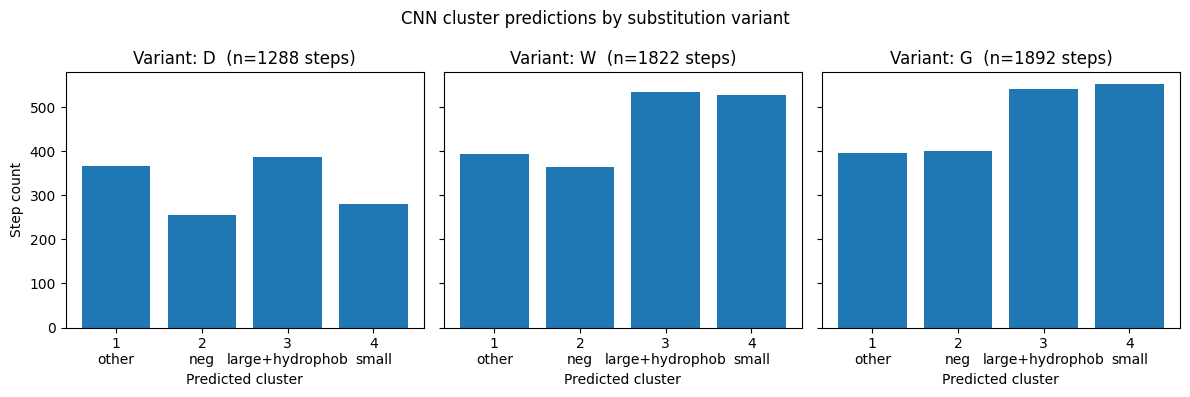

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, var in zip(axes, ['D', 'W', 'G']):
    subset = df[df['variant'] == var]['pred_cluster']
    counts = subset.value_counts().sort_index()
    ax.bar(counts.index, counts.values)
    ax.set_title(f'Variant: {var}  (n={len(subset)} steps)')
    ax.set_xlabel('Predicted cluster')
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xticklabels(['1\nother', '2\nneg', '3\nlarge+hydrophob', '4\nsmall'])

axes[0].set_ylabel('Step count')
plt.suptitle('CNN cluster predictions by substitution variant')
plt.tight_layout()
plt.show()
